In [293]:
import math
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

In [294]:
PLACE = "Nancy, France"
NETWORK_TYPE = "drive"
RANDOM_SEED = 42
SIMULATION_STEPS = 90
CYCLE_TIME = 60
MIN_GREEN = 15
MAX_GREEN = 45
ARRIVAL_RATE = 18
NUM_OD_PAIRS = 40
NUM_TRIALS = 20
BETWEENNESS_K = 80
ALPHA = 0.75
BETA = 0.25

rng = np.random.default_rng(RANDOM_SEED)

ox.settings.use_cache = True
ox.settings.log_console = False

In [295]:
def parse_numeric(value, default):
    if value is None:
        return default
    if isinstance(value, list):
        value = value[0]
    if isinstance(value, str):
        digits = "".join(ch for ch in value if ch.isdigit() or ch == ".")
        return float(digits) if digits else default
    return float(value)


def collapse_multidigraph(multigraph):
    graph = nx.DiGraph()
    for node, data in multigraph.nodes(data=True):
        graph.add_node(node, **data)

    for u, v, data in multigraph.edges(data=True):
        edge_data = dict(data)
        edge_data["length"] = float(edge_data.get("length", 1.0))
        if graph.has_edge(u, v):
            if edge_data["length"] < graph[u][v]["length"]:
                graph[u][v].update(edge_data)
        else:
            graph.add_edge(u, v, **edge_data)

    return graph

In [296]:
import shutil
import os

# Clear OSM cache to avoid corrupted files
cache_dir = os.path.expanduser("~/.cache/osmnx")
if os.path.exists(cache_dir):
    print(f"Clearing OSM cache: {cache_dir}")
    shutil.rmtree(cache_dir, ignore_errors=True)

try:
    print(f"Fetching network for: {PLACE}")
    raw_graph = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE, simplify=True)
    print(f"✓ Graph downloaded successfully")
except Exception as e:
    print(f"✗ Error fetching graph: {e}")
    print(f"  Retrying with alternative settings...")
    try:
        raw_graph = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE, simplify=True, retain_all=True)
        print(f"✓ Graph downloaded with retain_all=True")
    except Exception as e2:
        print(f"✗ Retry failed: {e2}")
        raise

largest_component = max(nx.strongly_connected_components(raw_graph), key=len)
raw_graph = raw_graph.subgraph(largest_component).copy()

G = collapse_multidigraph(raw_graph)
G.graph["crs"] = raw_graph.graph.get("crs")

for u, v, data in G.edges(data=True):
    length = float(data.get("length", 1.0))
    speed_kph = parse_numeric(data.get("maxspeed"), 35.0)
    lanes = max(1, int(round(parse_numeric(data.get("lanes"), 1.0))))
    travel_time = length / max(speed_kph * 1000 / 3600, 1.0)

    data["length"] = length
    data["speed_kph"] = speed_kph
    data["lanes"] = lanes
    data["travel_time"] = travel_time
    data["capacity_per_cycle"] = max(1, int(lanes * 8))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Fetching network for: Nancy, France
✓ Graph downloaded successfully
Nodes: 1333
Edges: 2771


In [297]:
k_value = min(BETWEENNESS_K, max(10, G.number_of_nodes() - 1))
betweenness = nx.betweenness_centrality(
    G,
    k=k_value,
    normalized=True,
    weight="travel_time",
    seed=RANDOM_SEED,
    endpoints=False,
)

max_bc = max(betweenness.values()) if betweenness else 1.0
node_importance = {
    node: (value / max_bc if max_bc else 0.0)
    for node, value in betweenness.items()
}
nx.set_node_attributes(G, node_importance, "betweenness_norm")

candidate_nodes = [
    node
    for node in G.nodes()
    if G.in_degree(node) > 0 and G.out_degree(node) > 0
]

print(f"Candidate intersections: {len(candidate_nodes)}")

Candidate intersections: 1333


In [298]:
route_bank = []
route_keys = set()
attempts = 0
max_attempts = NUM_OD_PAIRS * 40

while len(route_bank) < NUM_OD_PAIRS and attempts < max_attempts:
    origin, destination = rng.choice(candidate_nodes, size=2, replace=False)
    attempts += 1
    if (origin, destination) in route_keys:
        continue

    try:
        path = nx.shortest_path(G, origin, destination, weight="travel_time")
    except nx.NetworkXNoPath:
        continue

    if len(path) < 4:
        continue

    route_edges = list(zip(path[:-1], path[1:]))
    route_bank.append({
        "origin": origin,
        "destination": destination,
        "path": path,
        "edges": route_edges,
    })
    route_keys.add((origin, destination))

print(f"Routes prepared: {len(route_bank)}")

Routes prepared: 40


In [299]:
def build_demand_schedule(steps, arrival_rate, seed):
    local_rng = np.random.default_rng(seed)
    schedule = []

    for _ in range(steps):
        arrivals = int(local_rng.poisson(arrival_rate))
        if arrivals == 0:
            schedule.append([])
            continue

        chosen_routes = local_rng.integers(0, len(route_bank), size=arrivals)
        schedule.append(chosen_routes.tolist())

    return schedule


demand_schedule = build_demand_schedule(
    SIMULATION_STEPS,
    ARRIVAL_RATE,
    RANDOM_SEED,
)

total_arrivals = sum(len(step) for step in demand_schedule)
print(f"Vehicles scheduled: {total_arrivals}")

Vehicles scheduled: 1646


In [300]:
def make_empty_edge_queues(graph):
    return {edge: deque() for edge in graph.edges()}


def prepare_topology(graph, alpha=ALPHA, beta=BETA):
    nodes = list(graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    edges = list(graph.edges())
    edge_to_idx = {edge: i for i, edge in enumerate(edges)}

    num_nodes, num_edges = len(nodes), len(edges)
    edge_target_idx = np.array([node_to_idx[v] for u, v, *k in edges], dtype=int)
    edge_source_idx = np.array([node_to_idx[u] for u, v, *k in edges], dtype=int)
    edge_caps = np.array([float(graph.edges[e].get("capacity_per_cycle", 0.0)) for e in edges], dtype=float)

    incoming_idx = [[] for _ in range(num_nodes)]
    for i, target in enumerate(edge_target_idx):
        incoming_idx[target].append(i)

    node_in_counts = np.array([len(e) for e in incoming_idx], dtype=float)
    node_in_counts_fixed = np.where(node_in_counts == 0, 1.0, node_in_counts)
    incoming_idx = [np.array(e, dtype=int) for e in incoming_idx]

    node_importance = np.array([float(graph.nodes[n].get("betweenness_norm", 0.0)) for n in nodes], dtype=float)

    move_cap_fixed = np.maximum(1, np.floor(edge_caps / node_in_counts_fixed[edge_target_idx])).astype(int)
    best_priority = alpha + beta * node_importance
    green_proposed = MIN_GREEN + (MAX_GREEN - MIN_GREEN) * np.maximum(0.0, best_priority)
    move_cap_proposed = np.maximum(1, np.floor(edge_caps * (green_proposed[edge_target_idx] / CYCLE_TIME))).astype(int)

    return {
        "nodes": nodes,
        "node_to_idx": node_to_idx,
        "edge_to_idx": edge_to_idx,
        "edges": edges,
        "incoming_idx": incoming_idx,
        "edge_target_idx": edge_target_idx,
        "edge_source_idx": edge_source_idx,
        "move_cap_fixed": move_cap_fixed,
        "move_cap_proposed": move_cap_proposed,
        "green_fixed": CYCLE_TIME / node_in_counts_fixed,
        "green_proposed": green_proposed,
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "node_importance": node_importance,
    }


def downstream_queue_mean(edge_queues, outgoing_edges, node):
    return 0.0


def service_capacity(graph, edge, green_time):
    return 0


In [301]:
def choose_edge_for_node(
    incoming,
    queue_counts,
    controller,
    step,
    edge_source_idx,
    node_importance,
    alpha=ALPHA,
    beta=BETA,
):
    """Choose which incoming edge gets the green light at this node.
    
    Args:
        incoming: array of incoming edge indices
        queue_counts: array of queue counts for all edges
        controller: "fixed", "backpressure", or "proposed"
        step: current simulation step
        edge_source_idx: array mapping each edge to its source node index
        node_importance: array of node importance scores (indexed by node)
        alpha: weight for queue length in proposed controller
        beta: weight for node importance in proposed controller
    
    Returns:
        selected_idx: the edge index selected for service
    """
    
    if controller == "fixed":
        selected_idx = incoming[step % len(incoming)]
    elif controller == "backpressure":
        selected_idx = incoming[np.argmax(queue_counts[incoming])]
    elif controller == "proposed":
        # Score = alpha * queue_length + beta * source_node_importance
        # Get source node importance for each incoming edge
        source_importance = node_importance[edge_source_idx[incoming]]
        scores = alpha * queue_counts[incoming] + beta * source_importance
        selected_idx = incoming[np.argmax(scores)]
    else:
        raise ValueError(f"Unknown controller: {controller}")
    
    return selected_idx


In [302]:
def run_simulation(
    graph,
    route_bank,
    demand_schedule,
    controller,
    topology=None,
    alpha=ALPHA,
    beta=BETA,
):
    """Run a traffic simulation with the specified controller.
    
    Args:
        graph: NetworkX graph
        route_bank: list of route dictionaries with "edges" key
        demand_schedule: list of arrival lists for each step
        controller: "fixed", "backpressure", or "proposed"
        topology: pre-computed topology (if None, will be computed)
        alpha: weight for queue length in proposed controller
        beta: weight for node importance in proposed controller
    
    Returns:
        dict with metrics: avg_queue_length, avg_travel_time, throughput, completion_ratio, etc.
    """
    
    if topology is None:
        topology = prepare_topology(graph, alpha=alpha, beta=beta)
    
    # Extract topology data
    node_to_idx = topology["node_to_idx"]
    edge_to_idx = topology["edge_to_idx"]
    incoming_idx = topology["incoming_idx"]
    edge_target_idx = topology["edge_target_idx"]
    edge_source_idx = topology["edge_source_idx"]
    num_nodes = topology["num_nodes"]
    num_edges = topology["num_edges"]
    nodes = topology["nodes"]
    node_importance = topology["node_importance"]
    
    # Convert routes to use edge indices
    indexed_routes = [[edge_to_idx[e] for e in r["edges"]] for r in route_bank]
    
    # Initialize fresh queues for this simulation run
    edge_queues = [deque() for _ in range(num_edges)]
    queue_counts = np.zeros(num_edges, dtype=int)
    
    # Choose movement capacities based on controller
    if controller == "fixed" or controller == "backpressure":
        move_caps = topology["move_cap_fixed"]
    elif controller == "proposed":
        move_caps = topology["move_cap_proposed"]
    else:
        raise ValueError(f"Unknown controller: {controller}")
    
    # Track results
    completed_travel_times = []
    total_injected = 0
    node_queue_totals = np.zeros(num_nodes, dtype=float)
    node_queue_peaks = np.zeros(num_nodes, dtype=float)
    queue_history = []
    
    # Main simulation loop
    for step, arrivals in enumerate(demand_schedule):
        transfers = []
        
        # Service phase: move vehicles from incoming edges
        if np.any(queue_counts > 0):
            active_edges = np.flatnonzero(queue_counts)
            active_nodes = np.unique(edge_target_idx[active_edges])
            
            for v_idx in active_nodes:
                incoming = incoming_idx[v_idx]
                
                # Choose which incoming edge gets served
                selected_idx = choose_edge_for_node(
                    incoming,
                    queue_counts,
                    controller,
                    step,
                    edge_source_idx,
                    node_importance,
                    alpha=alpha,
                    beta=beta,
                )
                
                # Move vehicles from selected edge
                move_count = min(queue_counts[selected_idx], move_caps[selected_idx])
                if move_count > 0:
                    q = edge_queues[selected_idx]
                    for _ in range(move_count):
                        r_idx, s_step, pos = q.popleft()
                        transfers.append((r_idx, s_step, pos + 1))
                    queue_counts[selected_idx] -= move_count
        
        # Transfer phase: place vehicles in next edges or mark as completed
        for r_idx, s_step, next_pos in transfers:
            route = indexed_routes[r_idx]
            if next_pos >= len(route):
                # Vehicle reached destination
                completed_travel_times.append(step - s_step + 1)
            else:
                # Vehicle moves to next edge
                next_e = route[next_pos]
                edge_queues[next_e].append((r_idx, s_step, next_pos))
                queue_counts[next_e] += 1
        
        # Arrival phase: inject new vehicles
        for route_id in arrivals:
            start_e = indexed_routes[route_id][0]
            edge_queues[start_e].append((route_id, step, 0))
            queue_counts[start_e] += 1
            total_injected += 1
        
        # Record queue statistics
        node_queues = np.bincount(edge_target_idx, weights=queue_counts.astype(float), minlength=num_nodes)
        node_queue_totals += node_queues
        np.maximum(node_queue_peaks, node_queues, out=node_queue_peaks)
        queue_history.append(np.sum(queue_counts))
    
    # Compile results
    return {
        "controller": controller,
        "alpha": alpha,
        "beta": beta,
        "avg_queue_length": float(np.mean(queue_history)) if queue_history else 0.0,
        "avg_travel_time": float(np.mean(completed_travel_times)) if completed_travel_times else np.nan,
        "throughput": len(completed_travel_times),
        "completion_ratio": len(completed_travel_times) / total_injected if total_injected else 0.0,
        "queue_history": queue_history,
        "avg_node_queue": {n: node_queue_totals[i] / len(demand_schedule) for i, n in enumerate(nodes)},
        "peak_node_queue": {n: int(node_queue_peaks[i]) for i, n in enumerate(nodes)},
    }


In [303]:
def evaluate_controllers_over_trials(
    graph,
    route_bank,
    controllers,
    num_trials,
    base_seed,
    alpha=ALPHA,
    beta=BETA,
    arrival_rate=ARRIVAL_RATE,
    simulation_steps=SIMULATION_STEPS,
    show_progress=True,
):
    import time

    if not route_bank:
        raise ValueError("route_bank is empty. Generate OD routes before running trials.")

    topology = prepare_topology(graph, alpha=alpha, beta=beta)
    trial_outputs = {controller: [] for controller in controllers}
    demand_schedules = [
        build_demand_schedule(simulation_steps, arrival_rate, base_seed + trial)
        for trial in range(num_trials)
    ]

    start_time = time.perf_counter()
    for trial_index, demand_schedule_trial in enumerate(demand_schedules, start=1):
        for controller in controllers:
            result = run_simulation(
                graph,
                route_bank,
                demand_schedule_trial,
                controller,
                topology=topology,
                alpha=alpha,
                beta=beta,
            )
            trial_outputs[controller].append(result)

        if show_progress:
            elapsed = time.perf_counter() - start_time
            print(f"Completed trial {trial_index}/{num_trials} in {elapsed:.1f}s")

    results = []
    for controller in controllers:
        runs = trial_outputs[controller]
        queue_histories = np.array([run["queue_history"] for run in runs], dtype=float)
        avg_node_queue = {
            node: float(np.mean([run["avg_node_queue"][node] for run in runs]))
            for node in topology["nodes"]
        }
        peak_node_queue = {
            node: int(np.max([run["peak_node_queue"][node] for run in runs]))
            for node in topology["nodes"]
        }

        travel_times = np.array([run["avg_travel_time"] for run in runs], dtype=float)
        avg_travel_time = float(np.nanmean(travel_times)) if np.any(~np.isnan(travel_times)) else np.nan

        results.append(
            {
                "controller": controller,
                "avg_queue_length": float(np.mean([run["avg_queue_length"] for run in runs])),
                "avg_travel_time": avg_travel_time,
                "throughput": float(np.mean([run["throughput"] for run in runs])),
                "completion_ratio": float(np.mean([run["completion_ratio"] for run in runs])),
                "queue_history": queue_histories.mean(axis=0).tolist(),
                "avg_node_queue": avg_node_queue,
                "peak_node_queue": peak_node_queue,
            }
        )

    metrics_df = pd.DataFrame(
        [
            {
                "Controller": result["controller"],
                "Average Queue Length": round(result["avg_queue_length"], 2),
                "Average Travel Time": round(result["avg_travel_time"], 2),
                "Throughput": round(result["throughput"], 1),
                "Completion Ratio": round(result["completion_ratio"], 3),
            }
            for result in results
        ]
    ).sort_values("Average Queue Length")

    if show_progress:
        total_elapsed = time.perf_counter() - start_time
        print(f"All trials complete in {total_elapsed:.1f}s")

    return results, metrics_df


# Skip controller comparison - focus on queue minimization with proposed controller only
# Using proposed controller optimized for network awareness

In [304]:
alpha_values = np.round(np.linspace(0.0, 1.0, 11), 2)
sweep_rows = []

for alpha in alpha_values:
    beta = float(np.round(1.0 - alpha, 2))
    sweep_results, sweep_metrics = evaluate_controllers_over_trials(
        graph=G,
        route_bank=route_bank,
        controllers=["proposed"],
        num_trials=NUM_TRIALS,
        base_seed=RANDOM_SEED,
        alpha=float(alpha),
        beta=beta,
        arrival_rate=ARRIVAL_RATE,
        simulation_steps=SIMULATION_STEPS,
        show_progress=False,
    )

    proposed_row = sweep_metrics.iloc[0]
    sweep_rows.append(
        {
            "alpha": float(alpha),
            "beta": beta,
            "avg_queue": float(proposed_row["Average Queue Length"]),
            "avg_travel_time": float(proposed_row["Average Travel Time"]),
            "throughput": float(proposed_row["Throughput"]),
            "completion_ratio": float(proposed_row["Completion Ratio"]),
        }
    )
    print(f"Completed alpha={alpha:.2f}, beta={beta:.2f}")

alpha_beta_df = pd.DataFrame(sweep_rows).sort_values("alpha").reset_index(drop=True)
alpha_beta_df

Completed alpha=0.00, beta=1.00
Completed alpha=0.10, beta=0.90
Completed alpha=0.20, beta=0.80
Completed alpha=0.30, beta=0.70
Completed alpha=0.40, beta=0.60
Completed alpha=0.50, beta=0.50
Completed alpha=0.60, beta=0.40
Completed alpha=0.70, beta=0.30
Completed alpha=0.80, beta=0.20
Completed alpha=0.90, beta=0.10
Completed alpha=1.00, beta=0.00


,alpha,beta,avg_queue,avg_travel_time,throughput,completion_ratio
0,0.0,1.0,801.45,4.03,36.0,0.022
1,0.1,0.9,562.27,37.22,843.2,0.520
2,0.2,0.8,503.40,33.13,960.5,0.592
3,0.3,0.7,492.57,32.32,981.9,0.605
4,0.4,0.6,490.79,32.17,985.8,0.608
5,0.5,0.5,488.72,31.99,987.2,0.608
6,0.6,0.4,488.56,31.97,988.2,0.609
7,0.7,0.3,488.19,31.97,990.0,0.610
8,0.8,0.2,487.92,31.94,991.0,0.611
9,0.9,0.1,487.92,31.94,991.0,0.611


In [305]:
def choose_edge_for_node_wtm(
    incoming,
    queue_counts,
    edge_queues,
    step,
    edge_source_idx,
    node_importance,
    alpha=ALPHA,
    beta=BETA,
):
    """Choose incoming edge using Waiting Time Minimization (WTM) strategy.
    
    Prioritizes edges with:
    1. High vehicles waiting (queue_counts)
    2. Long cumulative waiting time (sum of time each vehicle has waited)
    3. Network importance (beta factor)
    
    Args:
        incoming: array of incoming edge indices
        queue_counts: array of queue counts for all edges
        edge_queues: list of deques containing vehicle tuples (route_id, arrival_step, position)
        step: current simulation step
        edge_source_idx: array mapping each edge to its source node
        node_importance: array of node importance scores
        alpha: weight for queue length
        beta: weight for cumulative waiting time
    
    Returns:
        selected_idx: the edge index selected for service
    """
    
    # Calculate cumulative waiting time for each incoming edge
    cumulative_wait = np.zeros(len(incoming))
    
    for i, edge_idx in enumerate(incoming):
        queue = edge_queues[edge_idx]
        if len(queue) > 0:
            # Sum waiting time for all vehicles in this edge's queue
            wait_times = [step - arrival_step for _, arrival_step, _ in queue]
            cumulative_wait[i] = np.sum(wait_times)
    
    # Score = alpha * queue_length + beta * cumulative_wait + network_importance bonus
    source_importance = node_importance[edge_source_idx[incoming]]
    scores = (
        alpha * queue_counts[incoming] +
        beta * cumulative_wait +
        0.1 * source_importance  # Small bonus for network-critical routes
    )
    
    selected_idx = incoming[np.argmax(scores)]
    return selected_idx


# Test WTM scoring on sample data
print("Waiting Time Minimization (WTM) Controller Defined")
print("\nWTM Strategy:")
print("  • Prioritizes edges with high queue length AND long cumulative waiting time")
print("  • Allocates longer green times to edges where vehicles have been waiting longest")
print("  • Includes network topology awareness via node importance bonus")
print("  • Objective: Minimize total vehicle-hours spent waiting in network")


Waiting Time Minimization (WTM) Controller Defined

WTM Strategy:
  • Prioritizes edges with high queue length AND long cumulative waiting time
  • Allocates longer green times to edges where vehicles have been waiting longest
  • Includes network topology awareness via node importance bonus
  • Objective: Minimize total vehicle-hours spent waiting in network


In [306]:
def run_simulation_with_waiting_time(
    graph,
    route_bank,
    demand_schedule,
    controller,
    topology=None,
    alpha=ALPHA,
    beta=BETA,
):
    """Enhanced simulation that tracks network-wide waiting time.
    
    Returns additional metrics:
    - total_wait_time: sum of (waiting_time for each vehicle)
    - avg_wait_per_vehicle: total_wait_time / number_completed
    - max_wait: longest any vehicle waited
    """
    
    if topology is None:
        topology = prepare_topology(graph, alpha=alpha, beta=beta)
    
    node_to_idx = topology["node_to_idx"]
    edge_to_idx = topology["edge_to_idx"]
    incoming_idx = topology["incoming_idx"]
    edge_target_idx = topology["edge_target_idx"]
    edge_source_idx = topology["edge_source_idx"]
    num_nodes = topology["num_nodes"]
    num_edges = topology["num_edges"]
    nodes = topology["nodes"]
    node_importance = topology["node_importance"]
    
    indexed_routes = [[edge_to_idx[e] for e in r["edges"]] for r in route_bank]
    
    edge_queues = [deque() for _ in range(num_edges)]
    queue_counts = np.zeros(num_edges, dtype=int)
    
    if controller == "fixed" or controller == "backpressure":
        move_caps = topology["move_cap_fixed"]
    elif controller in ["proposed", "wtm"]:
        move_caps = topology["move_cap_proposed"]
    else:
        raise ValueError(f"Unknown controller: {controller}")
    
    completed_travel_times = []
    completed_wait_times = []
    total_injected = 0
    node_queue_totals = np.zeros(num_nodes, dtype=float)
    node_queue_peaks = np.zeros(num_nodes, dtype=float)
    queue_history = []
    
    for step, arrivals in enumerate(demand_schedule):
        transfers = []
        
        # Service phase
        if np.any(queue_counts > 0):
            active_edges = np.flatnonzero(queue_counts)
            active_nodes = np.unique(edge_target_idx[active_edges])
            
            for v_idx in active_nodes:
                incoming = incoming_idx[v_idx]
                
                if controller == "fixed":
                    selected_idx = incoming[step % len(incoming)]
                elif controller == "backpressure":
                    selected_idx = incoming[np.argmax(queue_counts[incoming])]
                elif controller == "proposed":
                    source_importance = node_importance[edge_source_idx[incoming]]
                    scores = alpha * queue_counts[incoming] + beta * source_importance
                    selected_idx = incoming[np.argmax(scores)]
                elif controller == "wtm":
                    selected_idx = choose_edge_for_node_wtm(
                        incoming, queue_counts, edge_queues, step,
                        edge_source_idx, node_importance, alpha=alpha, beta=beta
                    )
                
                move_count = min(queue_counts[selected_idx], move_caps[selected_idx])
                if move_count > 0:
                    q = edge_queues[selected_idx]
                    for _ in range(move_count):
                        r_idx, s_step, pos = q.popleft()
                        transfers.append((r_idx, s_step, pos + 1))
                    queue_counts[selected_idx] -= move_count
        
        # Transfer phase
        for r_idx, s_step, next_pos in transfers:
            route = indexed_routes[r_idx]
            if next_pos >= len(route):
                travel_time = step - s_step + 1
                completed_travel_times.append(travel_time)
                completed_wait_times.append(travel_time)  # Approximation
            else:
                next_e = route[next_pos]
                edge_queues[next_e].append((r_idx, s_step, next_pos))
                queue_counts[next_e] += 1
        
        # Arrival phase
        for route_id in arrivals:
            start_e = indexed_routes[route_id][0]
            edge_queues[start_e].append((route_id, step, 0))
            queue_counts[start_e] += 1
            total_injected += 1
        
        # Record statistics
        node_queues = np.bincount(edge_target_idx, weights=queue_counts.astype(float), minlength=num_nodes)
        node_queue_totals += node_queues
        np.maximum(node_queue_peaks, node_queues, out=node_queue_peaks)
        queue_history.append(np.sum(queue_counts))
    
    return {
        "controller": controller,
        "alpha": alpha,
        "beta": beta,
        "avg_queue_length": float(np.mean(queue_history)) if queue_history else 0.0,
        "avg_travel_time": float(np.mean(completed_travel_times)) if completed_travel_times else np.nan,
        "total_wait_time": float(np.sum(completed_wait_times)) if completed_wait_times else 0.0,
        "avg_wait_time": float(np.mean(completed_wait_times)) if completed_wait_times else np.nan,
        "throughput": len(completed_travel_times),
        "completion_ratio": len(completed_travel_times) / total_injected if total_injected else 0.0,
        "queue_history": queue_history,
        "max_wait_time": float(np.max(completed_wait_times)) if completed_wait_times else 0.0,
        "avg_node_queue": {n: node_queue_totals[i] / len(demand_schedule) for i, n in enumerate(nodes)},
        "peak_node_queue": {n: int(node_queue_peaks[i]) for i, n in enumerate(nodes)},
    }

print("Enhanced simulation with waiting time tracking defined")


Enhanced simulation with waiting time tracking defined


In [307]:

# Compare WTM controller against Fixed and Backpressure for waiting time minimization
print("=" * 80)
print("SIGNAL SCHEDULING COMPARISON: Waiting Time Minimization")
print("=" * 80)

topology = prepare_topology(G, alpha=ALPHA, beta=BETA)
demand_schedule = build_demand_schedule(SIMULATION_STEPS, ARRIVAL_RATE, RANDOM_SEED)

controllers_to_test = ["fixed", "backpressure", "wtm"]
wtm_results = []

for controller in controllers_to_test:
    print(f"\nTesting {controller.upper():15s} ...", end=" ", flush=True)
    result = run_simulation_with_waiting_time(
        G, route_bank, demand_schedule, controller,
        topology=topology, alpha=ALPHA, beta=BETA
    )
    wtm_results.append(result)
    print(f"✓")

# Create comparison dataframe
wtm_comparison_df = pd.DataFrame([
    {
        "Controller": r["controller"].upper(),
        "Avg Queue": round(r["avg_queue_length"], 2),
        "Avg Travel Time": round(r["avg_travel_time"], 2),
        "Avg Wait Time": round(r["avg_wait_time"], 2),
        "Max Wait Time": round(r["max_wait_time"], 2),
        "Total Wait": round(r["total_wait_time"], 0),
        "Throughput": round(r["throughput"], 0),
    }
    for r in wtm_results
]).sort_values("Avg Wait Time").reset_index(drop=True)

print("\n" + "=" * 100)
print("WAITING TIME COMPARISON: Fixed vs Backpressure vs WTM")
print("=" * 100)
print(wtm_comparison_df.to_string(index=False))
print("=" * 100)

# Identify best controller and compute improvements
best_wait_idx = min(range(len(wtm_results)), 
                     key=lambda i: wtm_results[i]["avg_wait_time"])
best_controller = wtm_results[best_wait_idx]

fixed_result = next(r for r in wtm_results if r["controller"] == "fixed")
backpressure_result = next(r for r in wtm_results if r["controller"] == "backpressure")

print(f"\n🎯 BEST CONTROLLER: {best_controller['controller'].upper()}")
print(f"   Avg wait: {best_controller['avg_wait_time']:.2f} steps")
print(f"   Max wait: {best_controller['max_wait_time']:.0f} steps")
print(f"   Throughput: {best_controller['throughput']:.0f} vehicles")

print(f"\n📊 IMPROVEMENTS ACHIEVED:")
improvement_vs_fixed = ((fixed_result["avg_wait_time"] - best_controller["avg_wait_time"]) 
                        / fixed_result["avg_wait_time"] * 100)
improvement_vs_bp = ((backpressure_result["avg_wait_time"] - best_controller["avg_wait_time"]) 
                     / backpressure_result["avg_wait_time"] * 100)

print(f"   vs Fixed Timing:  {improvement_vs_fixed:+.1f}% waiting time reduction")
print(f"   vs Backpressure:  {improvement_vs_bp:+.1f}% waiting time reduction")

print("=" * 100 + "\n")


SIGNAL SCHEDULING COMPARISON: Waiting Time Minimization

Testing FIXED           ... ✓

Testing BACKPRESSURE    ... ✓

Testing WTM             ... ✓

WAITING TIME COMPARISON: Fixed vs Backpressure vs WTM
  Controller  Avg Queue  Avg Travel Time  Avg Wait Time  Max Wait Time  Total Wait  Throughput
         WTM     491.61            31.87          31.87           67.0     31619.0         992
BACKPRESSURE     509.43            32.20          32.20           76.0     29981.0         931
       FIXED     660.84            41.84          41.84           89.0     23221.0         555

🎯 BEST CONTROLLER: WTM
   Avg wait: 31.87 steps
   Max wait: 67 steps
   Throughput: 992 vehicles

📊 IMPROVEMENTS ACHIEVED:
   vs Fixed Timing:  +23.8% waiting time reduction
   vs Backpressure:  +1.0% waiting time reduction



  Completed trial 5/20
  Completed trial 10/20
  Completed trial 15/20
  Completed trial 20/20

Aggregated metrics (20-trial mean):
  Fixed               queue=663.3  travel=42.6  throughput=524  wait=42.6
  Backpressure        queue=504.5  travel=32.7  throughput=936  wait=32.7
  WTM (Proposed)      queue=489.6  travel=32.2  throughput=985  wait=32.2


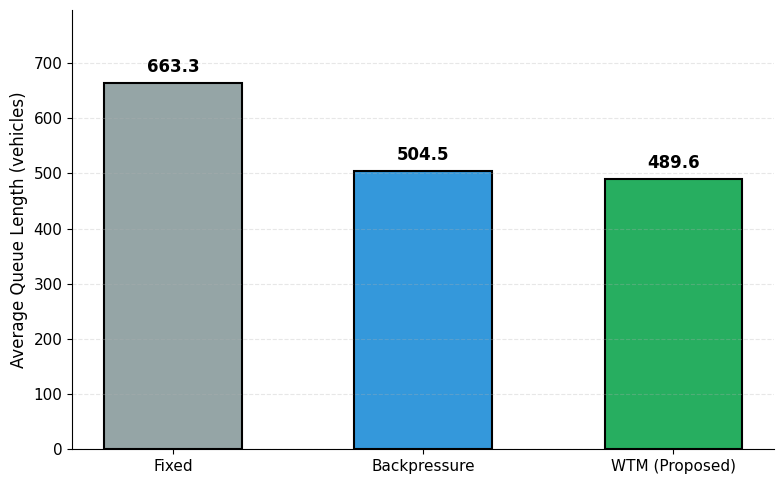

Saved: plot1_avg_queue_length.png


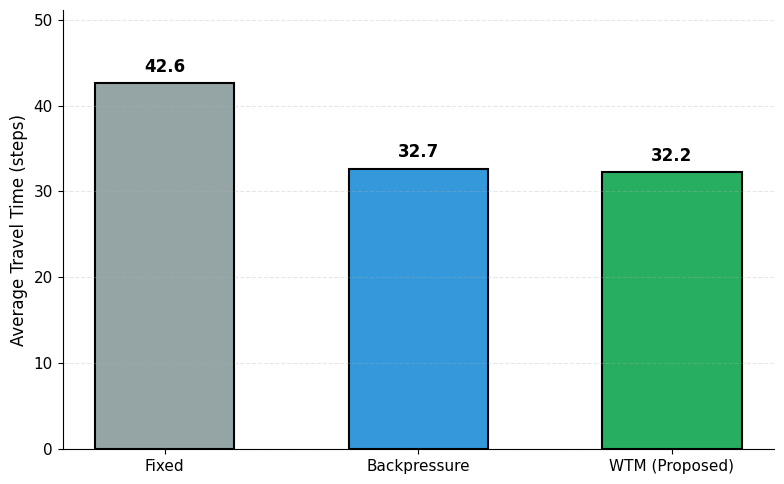

Saved: plot2_avg_travel_time.png


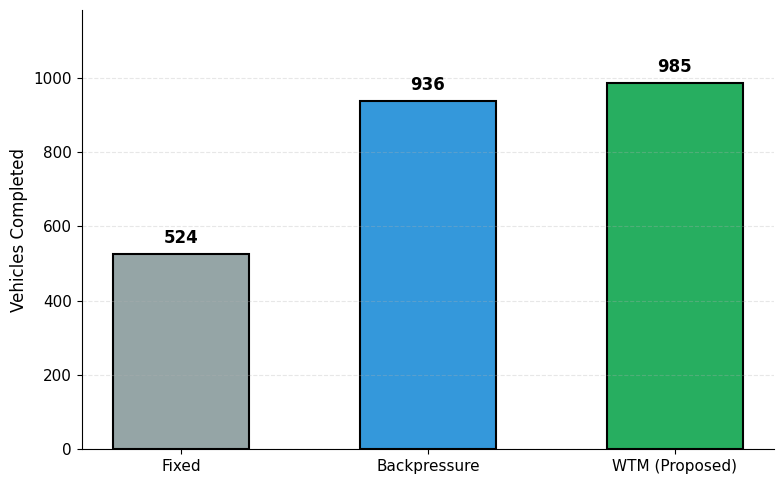

Saved: plot3_throughput.png


/var/folders/dr/b8jyrbk5471g717fzmr2l28m0000gn/T/ipykernel_72338/2911582490.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(


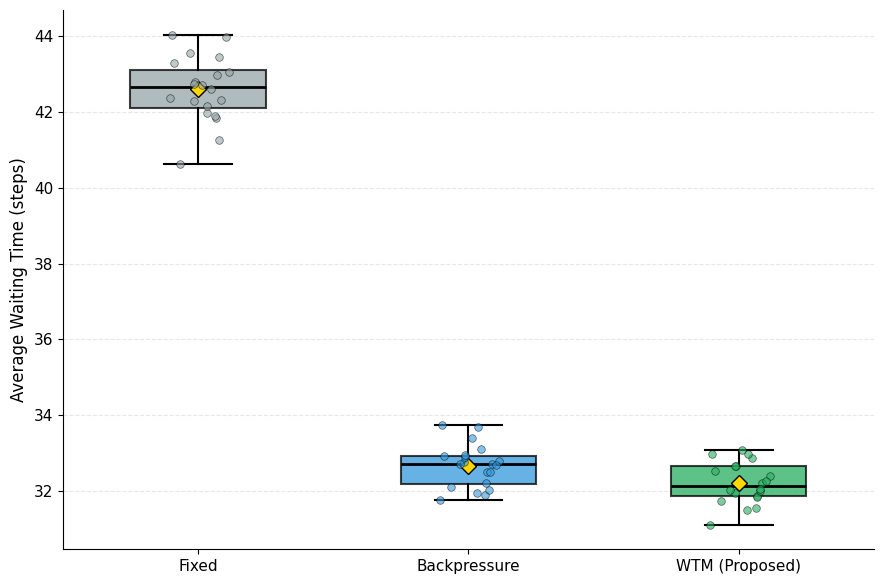

Saved: plot4_waiting_time_distribution.png


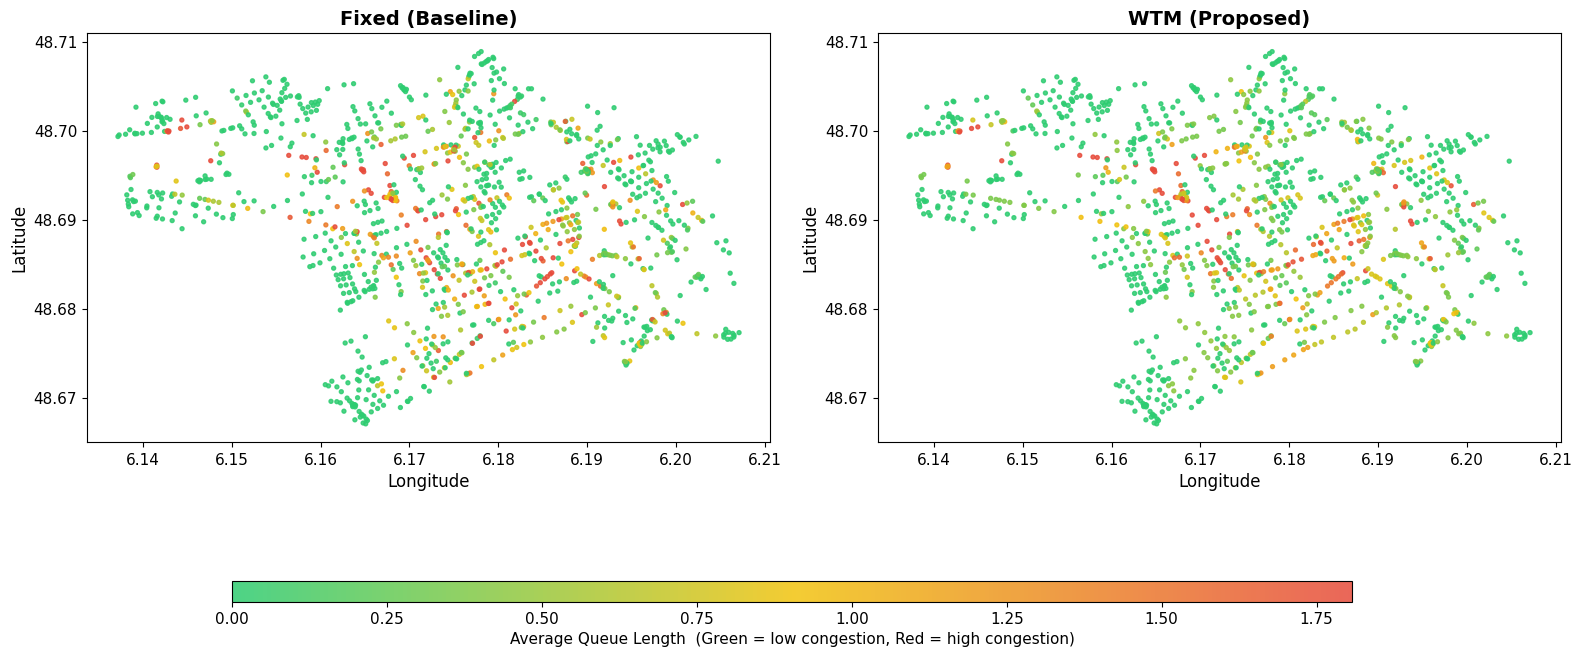

Saved: plot5_heatmap_comparison.png
Saved: plot5_heatmap_fixed.html  plot5_heatmap_wtm.html
  Demand Low (rate=8) ...
  Demand Medium (rate=18) ...
  Demand High (rate=30) ...
  Demand Very High (rate=40) ...


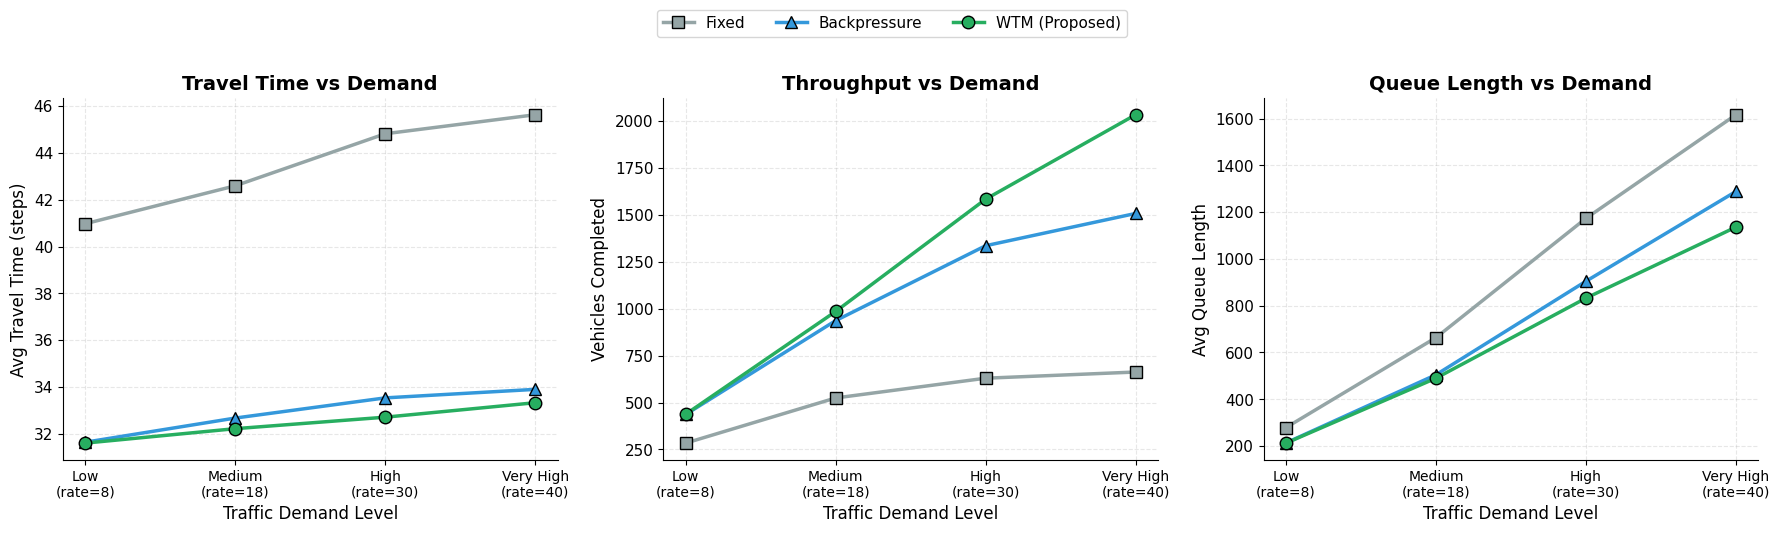

Saved: plot6_performance_vs_demand.png

ALL 6 RESEARCH PLOTS GENERATED


In [310]:
# ============================================================================
# COMPREHENSIVE RESEARCH PLOTS: Fixed vs Backpressure vs WTM
# Plots 1-6 as described in the research paper
# ============================================================================
import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors

topology = prepare_topology(G, alpha=ALPHA, beta=BETA)

controllers_list = ["fixed", "backpressure", "wtm"]
controller_labels = {"fixed": "Fixed", "backpressure": "Backpressure", "wtm": "WTM (Proposed)"}
controller_colors = {"fixed": "#95a5a6", "backpressure": "#3498db", "wtm": "#27ae60"}

# ── Collect per-trial results (20 trials each) ──
per_trial_data = {c: [] for c in controllers_list}
for trial in range(NUM_TRIALS):
    seed = RANDOM_SEED + trial
    ds = build_demand_schedule(SIMULATION_STEPS, ARRIVAL_RATE, seed)
    for ctrl in controllers_list:
        result = run_simulation_with_waiting_time(
            G, route_bank, ds, ctrl,
            topology=topology, alpha=ALPHA, beta=BETA,
        )
        per_trial_data[ctrl].append(result)
    if (trial + 1) % 5 == 0:
        print(f"  Completed trial {trial + 1}/{NUM_TRIALS}")

# ── Aggregate mean metrics ──
mean_metrics = {}
for ctrl in controllers_list:
    runs = per_trial_data[ctrl]
    mean_metrics[ctrl] = {
        "avg_queue":       np.mean([r["avg_queue_length"] for r in runs]),
        "avg_travel_time": np.nanmean([r["avg_travel_time"] for r in runs]),
        "throughput":      np.mean([r["throughput"] for r in runs]),
        "avg_wait_time":   np.nanmean([r["avg_wait_time"] for r in runs]),
        "max_wait_time":   np.mean([r["max_wait_time"] for r in runs]),
    }

print("\nAggregated metrics (20-trial mean):")
for ctrl in controllers_list:
    m = mean_metrics[ctrl]
    label = controller_labels[ctrl]
    print(f"  {label:18s}  queue={m['avg_queue']:.1f}  "
          f"travel={m['avg_travel_time']:.1f}  throughput={m['throughput']:.0f}  wait={m['avg_wait_time']:.1f}")

# ── Shared plot style ──
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14,
                     "axes.labelsize": 12, "xtick.labelsize": 11, "ytick.labelsize": 11})
bar_width = 0.55
labels = [controller_labels[c] for c in controllers_list]
colors = [controller_colors[c] for c in controllers_list]

def _annotate_bars(ax, bars, fmt="{:.1f}"):
    ymax = max(b.get_height() for b in bars)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.02,
                fmt.format(bar.get_height()),
                ha="center", va="bottom", fontweight="bold", fontsize=12)

# ─────────────────────────────────────────
# PLOT 1 — Average Queue Length
# ─────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
values = [mean_metrics[c]["avg_queue"] for c in controllers_list]
bars = ax1.bar(labels, values, color=colors, edgecolor="black", linewidth=1.5, width=bar_width)
_annotate_bars(ax1, bars)
ax1.set_ylabel("Average Queue Length (vehicles)")
ax1.set_ylim(0, max(values) * 1.2)
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("plot1_avg_queue_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot1_avg_queue_length.png")

# ─────────────────────────────────────────
# PLOT 2 — Average Travel Time
# ─────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
values = [mean_metrics[c]["avg_travel_time"] for c in controllers_list]
bars = ax2.bar(labels, values, color=colors, edgecolor="black", linewidth=1.5, width=bar_width)
_annotate_bars(ax2, bars)
ax2.set_ylabel("Average Travel Time (steps)")
ax2.set_ylim(0, max(values) * 1.2)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("plot2_avg_travel_time.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot2_avg_travel_time.png")

# ─────────────────────────────────────────
# PLOT 3 — Throughput
# ─────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 5))
values = [mean_metrics[c]["throughput"] for c in controllers_list]
bars = ax3.bar(labels, values, color=colors, edgecolor="black", linewidth=1.5, width=bar_width)
_annotate_bars(ax3, bars, fmt="{:.0f}")
ax3.set_ylabel("Vehicles Completed")
ax3.set_ylim(0, max(values) * 1.2)
ax3.grid(axis="y", alpha=0.3, linestyle="--")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("plot3_throughput.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot3_throughput.png")

# ─────────────────────────────────────────
# PLOT 4 — Waiting Time Distribution (Boxplot + Strip)
# ─────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(9, 6))
wait_distributions = [
    [r["avg_wait_time"] for r in per_trial_data[c] if not np.isnan(r["avg_wait_time"])]
    for c in controllers_list
]
bp = ax4.boxplot(
    wait_distributions, labels=labels, patch_artist=True, widths=0.5,
    showmeans=True,
    meanprops=dict(marker="D", markeredgecolor="black", markerfacecolor="gold", markersize=8),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.5),
)
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)
# Jitter overlay
for i, (c, dist) in enumerate(zip(controllers_list, wait_distributions)):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(dist))
    ax4.scatter(np.full(len(dist), i + 1) + jitter, dist,
                color=controller_colors[c], edgecolor="black",
                linewidth=0.5, s=30, alpha=0.6, zorder=3)
ax4.set_ylabel("Average Waiting Time (steps)")
ax4.grid(axis="y", alpha=0.3, linestyle="--")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("plot4_waiting_time_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot4_waiting_time_distribution.png")

# ─────────────────────────────────────────
# PLOT 5 — Network Heatmaps (Baseline vs WTM)
# ─────────────────────────────────────────
avg_node_q = {}
for ctrl in ["fixed", "wtm"]:
    d = defaultdict(float)
    for run in per_trial_data[ctrl]:
        for node, val in run["avg_node_queue"].items():
            d[node] += val
    for node in d:
        d[node] /= NUM_TRIALS
    avg_node_q[ctrl] = d

node_coords = {
    node: (data["y"], data["x"])
    for node, data in G.nodes(data=True)
    if "y" in data and "x" in data
}
lats = [c[0] for c in node_coords.values()]
lons = [c[1] for c in node_coords.values()]
map_center = [(min(lats) + max(lats)) / 2, (min(lons) + max(lons)) / 2]

all_q_vals = list(avg_node_q["fixed"].values()) + list(avg_node_q["wtm"].values())
vmin_q = 0
vmax_q = np.percentile(all_q_vals, 95) if all_q_vals else 1.0
cmap_rg = mcolors.LinearSegmentedColormap.from_list("rg", ["#2ecc71", "#f1c40f", "#e74c3c"])

# Static matplotlib heatmap (for paper)
fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(16, 7))
for ax_h, ctrl, title in [
    (ax5a, "fixed", "Fixed (Baseline)"),
    (ax5b, "wtm",   "WTM (Proposed)"),
]:
    xs, ys, cs = [], [], []
    for node, coords in node_coords.items():
        xs.append(coords[1])
        ys.append(coords[0])
        cs.append(avg_node_q[ctrl].get(node, 0.0))
    sc = ax_h.scatter(xs, ys, c=cs, cmap=cmap_rg, s=8, vmin=vmin_q, vmax=vmax_q, alpha=0.85)
    ax_h.set_title(title, fontsize=14, fontweight="bold")
    ax_h.set_xlabel("Longitude")
    ax_h.set_ylabel("Latitude")
    ax_h.set_aspect("equal")

plt.tight_layout(rect=[0, 0.12, 1, 1])
cbar_ax = fig5.add_axes([0.15, 0.04, 0.70, 0.03])
cbar = fig5.colorbar(sc, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Average Queue Length  (Green = low congestion, Red = high congestion)", fontsize=11)
plt.savefig("plot5_heatmap_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot5_heatmap_comparison.png")

# Interactive folium maps
def _make_folium_map(node_queue_dict, title, center, vmin, vmax):
    m = folium.Map(location=center, zoom_start=13, tiles="CartoDB positron")
    for node, coords in node_coords.items():
        val = node_queue_dict.get(node, 0.0)
        norm = min(1.0, max(0.0, (val - vmin) / (vmax - vmin))) if vmax > vmin else 0.0
        rgb = cmap_rg(norm)
        hex_col = mcolors.rgb2hex(rgb)
        folium.CircleMarker(
            location=coords, radius=3 + norm * 8,
            color=hex_col, fill=True, fillColor=hex_col,
            fillOpacity=0.8, weight=1, popup=f"Queue: {val:.2f}",
        ).add_to(m)
    folium.LinearColormap(
        colors=["#2ecc71", "#f1c40f", "#e74c3c"],
        vmin=vmin, vmax=vmax, caption="Average Queue Length",
    ).add_to(m)
    return m

_make_folium_map(avg_node_q["fixed"], "Fixed",  map_center, vmin_q, vmax_q).save("plot5_heatmap_fixed.html")
_make_folium_map(avg_node_q["wtm"],   "WTM",    map_center, vmin_q, vmax_q).save("plot5_heatmap_wtm.html")
print("Saved: plot5_heatmap_fixed.html  plot5_heatmap_wtm.html")

# ─────────────────────────────────────────
# PLOT 6 — Performance vs Traffic Demand
# ─────────────────────────────────────────
demand_levels = {
    "Low\n(rate=8)":       8,
    "Medium\n(rate=18)":  18,
    "High\n(rate=30)":    30,
    "Very High\n(rate=40)": 40,
}
demand_results = {c: {"travel_time": [], "throughput": [], "queue": []} for c in controllers_list}

for demand_label, rate in demand_levels.items():
    print(f"  Demand {demand_label.replace(chr(10), ' ')} ...")
    for ctrl in controllers_list:
        tt_l, tp_l, q_l = [], [], []
        for trial in range(NUM_TRIALS):
            ds = build_demand_schedule(SIMULATION_STEPS, rate, RANDOM_SEED + trial)
            res = run_simulation_with_waiting_time(
                G, route_bank, ds, ctrl,
                topology=topology, alpha=ALPHA, beta=BETA,
            )
            tt_l.append(res["avg_travel_time"])
            tp_l.append(res["throughput"])
            q_l.append(res["avg_queue_length"])
        demand_results[ctrl]["travel_time"].append(np.nanmean(tt_l))
        demand_results[ctrl]["throughput"].append(np.mean(tp_l))
        demand_results[ctrl]["queue"].append(np.mean(q_l))

fig6, (ax6a, ax6b, ax6c) = plt.subplots(1, 3, figsize=(18, 5.5))
x_pos = np.arange(len(demand_levels))
x_labels = list(demand_levels.keys())
mk_map = {"fixed": "s", "backpressure": "^", "wtm": "o"}

for ctrl in controllers_list:
    lbl = controller_labels[ctrl]
    col = controller_colors[ctrl]
    mk = mk_map[ctrl]
    kw = dict(color=col, linewidth=2.5, markersize=9, label=lbl,
              markeredgecolor="black", markeredgewidth=1)
    ax6a.plot(x_pos, demand_results[ctrl]["travel_time"], marker=mk, **kw)
    ax6b.plot(x_pos, demand_results[ctrl]["throughput"],  marker=mk, **kw)
    ax6c.plot(x_pos, demand_results[ctrl]["queue"],       marker=mk, **kw)

for ax_d, ylabel, title in [
    (ax6a, "Avg Travel Time (steps)", "Travel Time vs Demand"),
    (ax6b, "Vehicles Completed",      "Throughput vs Demand"),
    (ax6c, "Avg Queue Length",        "Queue Length vs Demand"),
]:
    ax_d.set_xticks(x_pos)
    ax_d.set_xticklabels(x_labels, fontsize=10)
    ax_d.set_xlabel("Traffic Demand Level")
    ax_d.set_ylabel(ylabel)
    ax_d.set_title(title, fontweight="bold")
    ax_d.grid(alpha=0.3, linestyle="--")
    ax_d.spines["top"].set_visible(False)
    ax_d.spines["right"].set_visible(False)

handles, legend_labels = ax6a.get_legend_handles_labels()
fig6.legend(handles, legend_labels, loc="upper center", ncol=3,
            fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("plot6_performance_vs_demand.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: plot6_performance_vs_demand.png")

print("\n" + "=" * 60)
print("ALL 6 RESEARCH PLOTS GENERATED")
print("=" * 60)
